# Cox-Ingersoll-Ross (CIR) Process Age Inference Algorithm for Age Estimation

This Jupyter Notebook demonstrates how to run Algorithm 2 of the paper [Lee et al., "Scalable and consistent sedimentation rate modeling via the Cox-Ingersoll-Ross (CIR) process for ocean sediment core age model development", 2026]. This algorithm is designed for sampling age-depth models from a single sediment record of (either or both) benthic d18O and radiocarbon proxies, given the CIR process model parameters. Please follow the lines below to estimate age-depth models.

For the model parameter estimation, please run Algorithm 1 of the paper, which is written in MATLAB. It can be found in the following GitHub link: xxxx

To start the age estimation, please execute the below cell first.

In [ ]:
############### DO NOT MODIFY BELOW ###############
import numpy as np
import cir_aligner as cir

CIR_aligner = cir.RECORD()

## Step 1. Identifying the Sediment Record

In [ ]:
# Provide the path to the d18O data. If only 14C data are available, let the path = ''. 
# The d18O data should be a csv file and consisting of two columns, depth and d18O. Depth should be in meters and d18O should be in permil.
path_to_d18O = 'Inputs/MD95-2042/data_d18O.csv'

# Provide the path to the 14C data. If only d18O data are available, let the path = ''. 
# The 14C data should be a csv file and consisting of six columns, depth, age, error, dR, dSTD and calibration model type (cc). 
# Depth should be in meters and age, error, dR and dSTD should be in kiloyears. 
# Calibration model type (cc) is specified as follows: 1 for IntCal20, 2 for Marine20, and 3 for SHCal20.
path_to_14C = 'Inputs/MD95-2042/data_14C.csv'

# Provide the path to the additional age information. If it does not exist, let the path = ''.
path_to_ETC = ''


############### DO NOT MODIFY BELOW ###############
CIR_aligner.init_data(path_to_d18O, path_to_14C, path_to_ETC)

## Step 2. Specifying the Model Parameters and Stack

In [ ]:
# Specify the model parameters, $\alpha$, $\beta$ and $\rho$, in the paper. 
# The default values are provided. You can modify those values if needed.
cir_alpha = 2
cir_beta = 1.922
cir_rho = 0.634

# Provide the path to the benthic d18O stack. Some published ones can be found in the folder 'Stacks/'.
path_to_d18O_stack = 'Stacks/DNEA.csv'


############### DO NOT MODIFY BELOW ###############
CIR_aligner.get_model_parameters(cir_alpha, cir_beta, cir_rho)
CIR_aligner.get_d18O_stack(path_to_d18O_stack)

## Step 3. Providing Record-specific Information

In [ ]:
# Specify parameters of the generalized Student's t-distributions for 14C and benthic d18O. 
# The default values are provided. You can modify those values if needed.
a_14C = 10
b_14C = 11
a_d18O = 3
b_d18O = 4

# Provide initial values of the benthic d18O scale and shift parameters.
initial_scale_d18O = 1
initial_shift_d18O = 0

# Provide initial value of the standardization parameter. 
# For example, one can simply initialize the standardization parameter with the whole depth change over the expected age range.
initial_std_param = 0.3333

# Provide the start depth in meters and the minimum age threshold in kiloyears at that depth. The default values are 0.0 meter and -0.1 kiloyear, respectively. 
# It means that the top of the sediment core cannot be younger than -0.1 kiloyear. If your record is expected to cover the Late Pleistocene, then this setting might make sense. 
# However, if your record is far older thus expected not to cover the very recent epoch, then please change those values appropriately, based on your prior knowledge.
start_depth = 0
minimum_age_thredhold = -0.1


############### DO NOT MODIFY BELOW ###############
CIR_aligner.get_record_specific_parameters(a_14C, b_14C, a_d18O, b_d18O, initial_scale_d18O, initial_shift_d18O, initial_std_param, start_depth, minimum_age_thredhold)

## Step 4. Configuring the Algorithm

In [ ]:
# Specify the number of EM iterations. The default value is 10.
num_EM_iteration = 10

# Specify the number of samples to draw. The default value is 1000.
num_samples = 1000

# Specify the size of inducing depths. The default is 100, but we recommend to modify into a natural number between the expected age range and four times the expected age range, in kiloyears.
num_inducing_depths = 212

# Specify whether or not to estimate benthic d18O scale and shift parameters. The default is 'True' for both, but you can set any of them 'False' if you just fix the corresponding value with its initialization.
islearn_d18O_scale = True
islearn_d18O_shift = True

# Specify whether or not to update the standardization parameter. The default is 'True', but you can set it 'False' if you just fix the corresponding value with its initialization.
islearn_std_param = True


############### DO NOT MODIFY BELOW ###############
CIR_aligner.get_inducing_depths(num_inducing_depths)

## Step 5. Running the Algorithm

In [ ]:
# Specify the path for storing outputs.
output_folder_path = 'Outputs/MD95-2042'


############### DO NOT MODIFY BELOW ###############
print("## Parameters are being estimated by the EM algorithm...")

for iters in range(num_EM_iteration):
    # Initialize posterior samples via the stein variational gradient descent algorithm:
    CIR_aligner.SVGD(3000,100)

    # Draw posterior samples via the Hamiltonian Monte Carlo algorithm:
    CIR_aligner.HMC(300,100)
        
    # Update the parameters:
    CIR_aligner.learnParam(islearn_d18O_scale,islearn_d18O_shift,islearn_std_param)

    print("#  Iteration " + str(iters+1) + '/' + str(num_EM_iteration) + ' is done.')
    print(f'   Standardization parameter is {(1.0/CIR_aligner.inv_std_param):.4f}.')
    if path_to_d18O != '':
        print(f'   Scale_d18O is {(CIR_aligner.scale_d18O):.4f}.')
        print(f'   Shift_d18O is {(CIR_aligner.shift_d18O):.4f}.')


print("## Parameters have been estimated. Samples are being drawn...")
# Initialize posterior samples via the stein variational gradient descent algorithm:
CIR_aligner.SVGD(3000,100)

# Draw posterior samples via the Hamiltonian Monte Carlo algorithm:
CIR_aligner.HMC(300,100)
CIR_aligner.HMC(200,num_samples)

# Store the outputs:
CIR_aligner.saveResults(output_folder_path)

## Step 6. Visualizaing the Results
- This step generates the figure just like those of three panels in the paper.

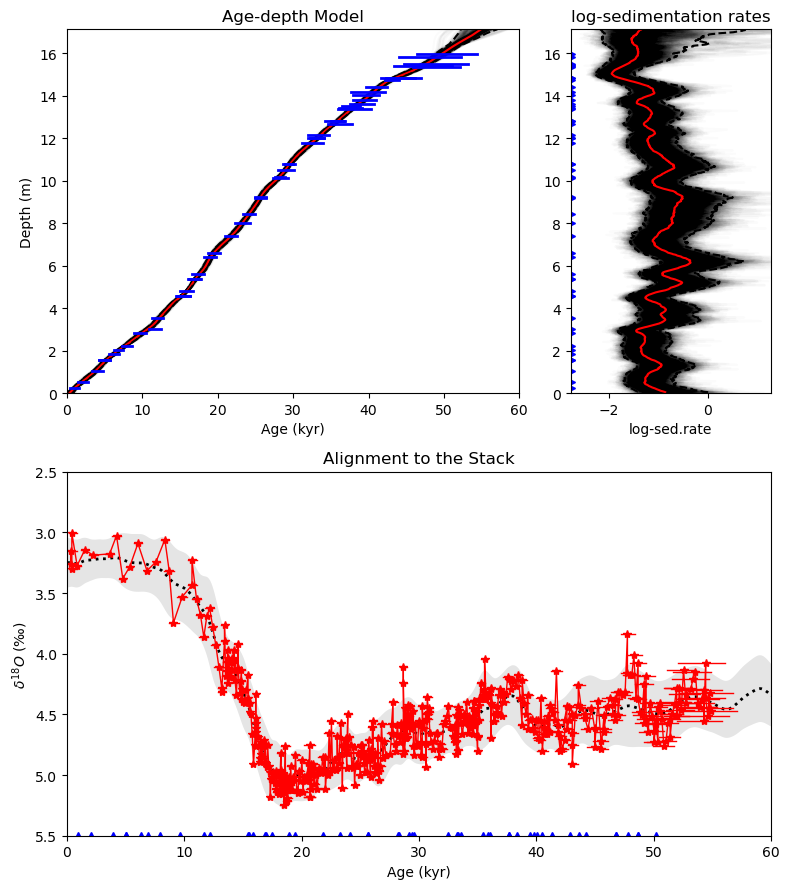

In [4]:
# Specify the range of age-depth model plot and alignment-to-stack plot.
age_min = 0
age_max = 60


# If you want to run this code separately, please specify the following accordingly. If you do not use d18O, then let path_to_d18O_stack = ''.
output_folder_path = 'Outputs/MD95-2042'
path_to_d18O_stack = 'Stacks/DNEA.csv'


# Optional: you can compare the sampled age-depth models with pointwise age estimates from 14C only by specifying its path as below. If you do not have one, then let path_to_individual_14C = ''.
path_to_individual_14C = 'C14_individual/MD95-2042.csv'


# You can modify the below code according to your purpose:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from pathlib import Path


if path_to_d18O_stack.strip() == '':
    fig = plt.figure(figsize=(8, 4.5), dpi=100)
else:
    fig = plt.figure(figsize=(8, 9), dpi=100)

AGE = pd.read_csv(output_folder_path + '/age_summary.csv')
AGE_IND = pd.read_csv(output_folder_path + '/age_inducing_summary.csv')
AGE_IND_SAMPLE = np.loadtxt(output_folder_path + '/age_inducing_samples.txt')

# age-depth model:
if path_to_d18O_stack.strip() == '':
    ax1 = plt.subplot(1, 3, (1, 2))
else:
    ax1 = plt.subplot(2, 3, (1, 2))
ax1.set_title("Age-depth Model", fontsize=12)

DD = np.concatenate([np.atleast_1d(AGE.depth).reshape(-1), np.atleast_1d(AGE_IND.depth).reshape(-1)])
LB = np.concatenate([np.atleast_1d(AGE.age_ci95_lower).reshape(-1), np.atleast_1d(AGE_IND.age_ci95_lower).reshape(-1)])
MB = np.concatenate([np.atleast_1d(AGE.age_median).reshape(-1), np.atleast_1d(AGE_IND.age_median).reshape(-1)])
UB = np.concatenate([np.atleast_1d(AGE.age_ci95_upper).reshape(-1), np.atleast_1d(AGE_IND.age_ci95_upper).reshape(-1)])

order = np.argsort(DD)
DD = DD[order]
LB = LB[order]
MB = MB[order]
UB = UB[order]

DD_unique, idx = np.unique(DD, return_index=True)
DD = DD_unique
LB = LB[idx]
MB = MB[idx]
UB = UB[idx]

TT = np.linspace(np.min(DD), np.max(DD), 1001)

LB_i = interp1d(DD, LB, kind="linear", bounds_error=False, fill_value="extrapolate")(TT)
MB_i = interp1d(DD, MB, kind="linear", bounds_error=False, fill_value="extrapolate")(TT)
UB_i = interp1d(DD, UB, kind="linear", bounds_error=False, fill_value="extrapolate")(TT)

ax1.plot(AGE_IND_SAMPLE, AGE_IND.depth, color="k", alpha=0.015)

ax1.plot(LB_i, TT, "--k")
ax1.plot(MB_i, TT, "r")
ax1.plot(UB_i, TT, "--k")

if path_to_individual_14C.strip() != '':
    C14_INDIV = pd.read_csv(path_to_individual_14C)
    for m in range(len(C14_INDIV.depth)):
        ax1.plot([C14_INDIV.age_ci95_lower[m], C14_INDIV.age_ci95_upper[m]], [C14_INDIV.depth[m], C14_INDIV.depth[m]], color="b", linewidth=2)

if Path(output_folder_path+'/ETC_summary.csv').exists():
    ETC_INDIV = pd.read_csv(output_folder_path+'/ETC_summary.csv')
    for m in range(len(ETC_INDIV.depth)):
        ax1.plot([ETC_INDIV.age_ci95_lower[m], ETC_INDIV.age_ci95_upper[m]], [ETC_INDIV.depth[m], ETC_INDIV.depth[m]], color="g", linewidth=2)

ax1.set_xlim([age_min, age_max])
ax1.set_ylim([np.min(DD), np.max(AGE.depth)])
ax1.set_xlabel("Age (kyr)", fontsize=10)
ax1.set_ylabel("Depth (m)", fontsize=10)

# log-sedrate:
if path_to_d18O_stack.strip() == '':
    ax2 = plt.subplot(1, 3, 3)
else:
    ax2 = plt.subplot(2, 3, 3)
ax2.set_title("log-sedimentation rates", fontsize=12)

D0 = np.loadtxt(output_folder_path + '/acc_rate_inducing_depths.txt')
A0 = np.loadtxt(output_folder_path + '/acc_rate_inducing.txt')

ACC_RATE = np.full((len(TT), D0.shape[1]), np.nan)

for k in range(D0.shape[1]):
    ACC_RATE[:, k] = interp1d(D0[:, k], np.log(A0[:, k]), kind="linear", bounds_error=False)(TT)

LB = np.quantile(ACC_RATE, 0.025, axis=1)
MB = np.quantile(ACC_RATE, 0.5, axis=1)
UB = np.quantile(ACC_RATE, 0.975, axis=1)

ax2.plot(ACC_RATE, TT, color="k", alpha=0.015)
ax2.plot(LB, TT, "--k")
ax2.plot(MB, TT, "r")
ax2.plot(UB, TT, "--k")

MIN = np.min(LB[~np.isnan(LB)]) - 0.5
MAX = np.max(UB[~np.isnan(UB)]) + 0.5

if path_to_individual_14C.strip() != '':
    ax2.plot(np.full(len(C14_INDIV.depth), MIN), C14_INDIV.depth, ">b", linewidth=1)

if Path(output_folder_path+'/ETC_summary.csv').exists():
    ax2.plot(np.full(len(ETC_INDIV.depth), MIN), ETC_INDIV.depth, linestyle="None", marker="s", color="g", linewidth=1)

ax2.set_xlim([MIN, MAX])
ax2.set_ylim([np.min(DD), np.max(AGE.depth)])
ax2.set_xlabel("log-sed.rate", fontsize=10)

# alignment to stack:
if path_to_d18O_stack.strip() != '':
    STACK = pd.read_csv(path_to_d18O_stack)

    d18O = pd.read_csv(output_folder_path + '/d18O_summary.csv')

    ax3 = plt.subplot(2, 3, (4, 6))
    ax3.set_title("Alignment to the Stack", fontsize=12)

    xx = np.concatenate([STACK['age'], np.flipud(STACK['age'])])
    yy = np.concatenate([STACK['mean']-1.96*STACK['sigma'], np.flipud(STACK['mean']+1.96*STACK['sigma'])])
    ax3.fill(xx, yy, color="k", alpha=0.10, edgecolor="none")
    ax3.plot(STACK['age'], STACK['mean'], ":k", linewidth=2)

    parameters = {}
    with open(output_folder_path+"/parameters.txt", "r") as f:
        for line in f:
            key, value = line.strip().split(":")
            parameters[key.strip()] = float(value.strip())

    shift_d18O = parameters["shift_d18O"]
    scale_d18O = parameters["scale_d18O"]

    YY = (d18O.d18O-shift_d18O)/scale_d18O

    AGE_lower = np.quantile(AGE, 0.025, axis=1)
    AGE_median = np.quantile(AGE, 0.5, axis=1)
    AGE_upper = np.quantile(AGE, 0.975, axis=1)

    for n in range(len(d18O.depth)):
        ax3.plot([d18O.age_ci95_lower[n], d18O.age_ci95_upper[n]], [YY[n], YY[n]], color="r", linewidth=1)

    order = np.argsort(d18O.age_median)
    ax3.plot(d18O.age_median[order], YY[order], "-*r", linewidth=1)

    if path_to_individual_14C.strip() != '':
        ax3.plot(C14_INDIV.age_median, 5.5*np.ones(len(C14_INDIV.age_median)), "^b", linewidth=1)

    if Path(output_folder_path+'/ETC_summary.csv').exists():
        ax3.plot(ETC_INDIV.age_median, 5.5*np.ones(len(ETC_INDIV.age_median)), linestyle="None", marker="s", color="g", linewidth=1)

    ax3.set_xlim([age_min, age_max])
    ax3.set_ylim([2.5, 5.5])
    ax3.invert_yaxis()
    ax3.set_xlabel("Age (kyr)", fontsize=10)
    ax3.set_ylabel(r'$\delta^{18}O$ (‰)', fontsize=10)

plt.tight_layout()

plt.savefig(output_folder_path+'/figure.png', bbox_inches='tight')

plt.show()